# Notebook compare the SSLimPy response functions to Sims

## Initial Setup

In [1]:
import os
import sys

sys.path.append("../")

envkey = "OMP_NUM_THREADS"
# Set this environment variable to the number of available cores in your machine,
# to get a fast execution of the Einstein Boltzmann Solver
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))
os.environ[envkey] = str(12)
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))

The value of OMP_NUM_THREADS is:  None
The value of OMP_NUM_THREADS is:  12


In [2]:
import astropy.units as u
import matplotlib.pyplot as plt
from copy import copy, deepcopy
import numpy as np
import seaborn
from getdist.gaussian_mixtures import GaussianND
from getdist import plots
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from matplotlib import cm, colors

In [3]:
# seaborn.set_theme(rc={'axes.edgecolor': 'black', 'xtick.color': 'black', 'ytick.color': 'black',})
import niceplots.utils as nicepl
nicepl.initPlot()

In [4]:
Cs = seaborn.color_palette("colorblind")
Cp = seaborn.color_palette("Paired")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [5]:
# Import Main modules. This might take some time as some functions compile before time
from SSLimPy.interface import sslimpy
from SSLimPy.cosmology import cosmology
from SSLimPy.cosmology import halo_model
from SSLimPy.cosmology import astro
from SSLimPy.LIMsurvey import covariance as scov
import SSLimPy.LIMsurvey.power_spectrum as spobs

## Choose model parameters and save them in dictionaries

In [6]:
settings = {
    "code":"class", # The Einstein--Boltzman solver that should be used
    "do_RSD" : False, # If RSD should be considerd
    "nonlinearRSD" : False, # If you want to add FOG to the RSD
    "QNLpowerspectrum": False, # Use dewiggled power spectrum (vlasov approximation of nonlinear structure formation)
    "FoG_damp" : "ISTF_like", # The particular parametrization for the FOG. Check PowerSpectrum for the full list
    "halo_model_PS" : True, # If the cosmological shotnoise should be computed from the halo model 
    "output" : ["Power spectrum", "Covariance"], # What output one wants (here power spectrum and Gaussian covariance only)
    "kmin": 1e-4 * u.Mpc**-1,
    "kmax": 50 * u.Mpc**-1,
    "nk": 200,
}

cosmodict={
    "h": 0.677,
    "Omegam": 0.309167,
    "Omegab": 0.04903,
    "sigma8":0.8222,
    "ns":0.96824,
    "mnu":0.06,
    "Neff":3.044,
}

# Parameters that enter your halo model. Typically they are not changed but you could
halodict={
    "halo_tracer" : "clustering", # Computes all halo quantities from the matter field - neutrinos
    "hmf_model": "ST", # Sheth--Tormann halo mass function
    "concentration": "Diemer19", # Diemer19 halo concentration relation
    "bias_model": "ST99",
}

In [7]:
# Parameters for the Survey specifications
z = np.array([1])
def get_specs(nu):
        nuObs = nu / (z + 1)
        DeltaDeltanu = 0.1

        surveyspecs = {
                "Tsys_NEFD": 0 * u.uK, #System temperature for instrumental shotnoise
                "Nfeeds": 19,
                "tobs": 1300 * u.h,
                "nD": 1, # Observational parameters
                "beam_FWHM": 0. * u.arcmin,
                "nu":  nu,
                "nuObs": nuObs, # Observed Frequency
                "Delta_nu": DeltaDeltanu * nuObs, # Frequency Bin
                "dnu": 0. * u.MHz, # Spectrograph resolution
                "Omega_field": 140 * u.deg**2, # Angular size of survey
        }
        return surveyspecs

# [CII]

In [31]:
astrodict_CII={
    "model_type": "ML",
    "model_name": "SilvaCII",
    "model_par": {
        "a": 0.8475,
        "b": 7.2203,
        "SFR_file": "sfr_release.dat",
        "do_quench": False,
    },
    "sigma_scatter" : 0.37,
    "meanperserve_scatter": False,
}

nu = 1.897 * u.THz
surveyspecs_CII = get_specs(nu)

In [32]:
myssl = sslimpy.SSLimPy(
    settings_dict=settings,
    cosmopars=cosmodict,
    halopars=halodict,
    astropars=astrodict_CII,
    obspars_dict=surveyspecs_CII,
)

myastro = myssl.current_astro
mycosmo = myastro.cosmology
h = mycosmo.h()

  █████   █████  █       █            █████   █    █ 
 █     █ █     █ █            █   █   █    █  █   █  
 █       █       █     ███   █ █ █ █  █    █   █ █   
  █████   █████  █       █   █  █  █  █████     █    
       █       █ █       █   █     █  █        █     
 █     █ █     █ █       █   █     █  █       █      
  █████   █████  █████ █████ █     █  █      █       

#---------------------------------------------------#


/home/sefa/Desktop/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:163: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


/home/sefa/Desktop/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/halo_model.py:573: RuntimeWarning: invalid value encountered in subtract
  np.cos(x) * (ci_cx - ci_x)
/home/sefa/Desktop/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/halo_model.py:575: RuntimeWarning: invalid value encountered in divide
  - np.sin(c * x) / ((1.0 + c) * x)


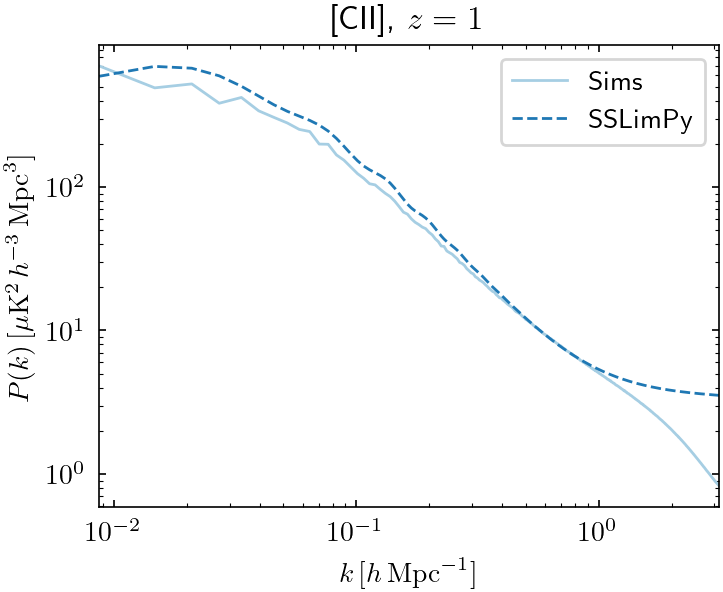

In [33]:
pk_az = np.loadtxt("/home/sefa/Desktop/LIM-Code/clusterdata/pkfliles_from_source/snapshot_a0.500/ModelCII_A_N1024/ModelCII_A_pks_1d_0.5000.txt")
k_az, Pk_az = pk_az[:, 0], pk_az[:, 1]

k_az = (k_az * myastro.Mpch**-1).to(myastro.Mpch**-1)
Pk_az = (Pk_az * myastro.Mpch**3 * u.uK**2).to(myastro.Mpch**3 * u.uK**2)

I11 = myastro.Thalo(z, k_az, p=1, scale=(1,), beta=1)
I02 = myastro.Thalo(z, k_az, p=1, scale=(2,), beta=0)
Pk_Lim_Solo = (I11**2) * mycosmo.matpow(k_az, z) + I02

plt.loglog(k_az, Pk_az, c=Cp[0], label="Sims")
plt.loglog(k_az, Pk_Lim_Solo.to(myastro.Mpch**3 * u.uK**2), c=Cp[1], ls="--", label="SSLimPy")

plt.xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)\,[\mu \mathrm{K}^2\,h^{-3}\,\mathrm{Mpc}^{3}]$")
plt.title(r"[CII], $z=1$")
plt.legend()

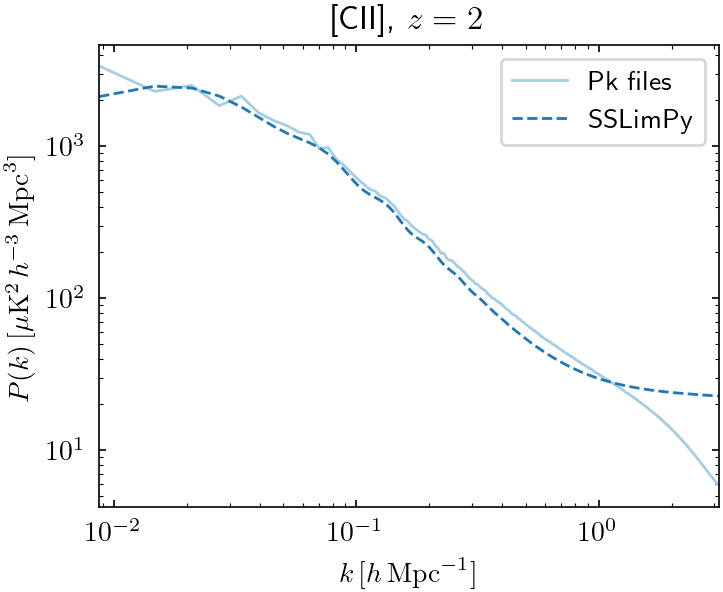

In [34]:
pk_az = np.loadtxt("/home/sefa/Desktop/LIM-Code/clusterdata/pkfliles_from_source/snapshot_a0.3333/ModelCII_A_N1024/ModelCII_A_pks_1d_0.3333.txt")
k_az, Pk_az = pk_az[:, 0], pk_az[:, 1]

k_az = (k_az * myastro.Mpch**-1).to(myastro.Mpch**-1)
Pk_az = (Pk_az * myastro.Mpch**3 * u.uK**2).to(myastro.Mpch**3 * u.uK**2)

I11 = myastro.Thalo(2, k_az, p=1, scale=(1,), beta=1)
I02 = myastro.Thalo(2, k_az, p=1, scale=(2,), beta=0)
Pk_Lim_Solo = (I11**2) * mycosmo.matpow(k_az, 2) + I02

plt.loglog(k_az, Pk_az, c=Cp[0], label="Pk files")
plt.loglog(k_az, Pk_Lim_Solo.to(myastro.Mpch**3 * u.uK**2), c=Cp[1], ls="--", label="SSLimPy")

plt.xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)\,[\mu \mathrm{K}^2\,h^{-3}\,\mathrm{Mpc}^{3}]$")
plt.title(r"[CII], $z=2$")
plt.legend()

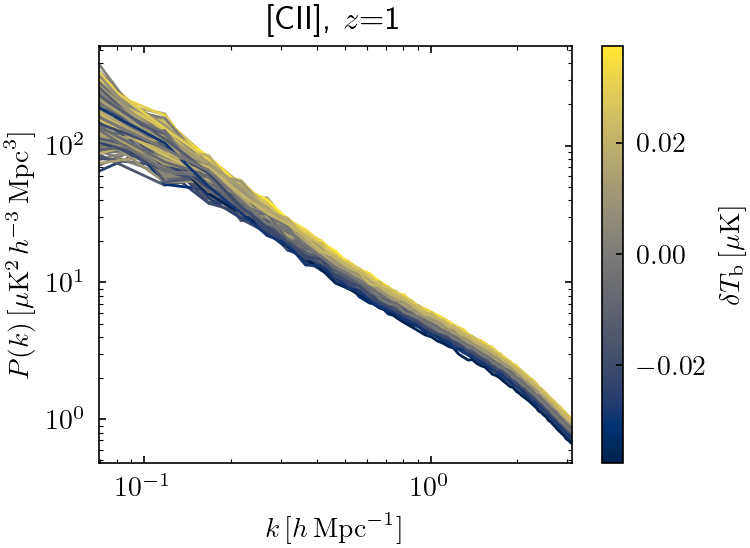

In [35]:
second = np.load("/home/sefa/Desktop/LIM-Code/clusterdata/run_189352_CII_A_Response_NSUB8.npz")
ks, Pks, db = second["k"], second["Pkmean"], second["deltab"]
ks = (ks * myastro.Mpch**-1).to(myastro.Mpch**-1)

# Set up colormap normalization
norm = colors.Normalize(vmin=np.min(db), vmax=np.max(db))
cmap = cm.cividis
sm = cm.ScalarMappable(norm=norm, cmap=cmap)  # for the colorbar

# Plot
fig, ax = plt.subplots()
for i in range(Pks.shape[0]):
    color = cmap(norm(db[i]))
    ax.loglog(ks[i, :], Pks[i, :], color=color)

# Add colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\delta T_\mathrm{b}\,[\mu\mathrm{K}]$")

ax.set_title(r"[CII], $z$=1")
ax.set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$P(k)\,[\mu \mathrm{K}^2\,h^{-3}\,\mathrm{Mpc}^{3}]$")
fig.tight_layout()
plt.show()

In [36]:
def linear(x, a, b):
    return a * x + b

pobs, pcov = [], []
for i in range(Pks.shape[1]):
    pi, ci = curve_fit(linear, db, Pks[:, i])
    pobs.append(pi)
    pcov.append(ci)
pobs = np.array(pobs)
pcov = np.array(pcov)

ai, bi = pobs[:, 0], pobs[:, 1]

ki = ks[0, :]
ri = myastro.Tavg(1).to(u.uK).value * ai / bi
si = ri * np.sqrt(pcov[:, 0, 0]/ ai**2 + pcov[:, 1, 1]/ bi**2 - 2 * bi / ai * pcov[:, 0, 1])

/tmp/ipykernel_26553/1165534172.py:15: RuntimeWarning: divide by zero encountered in divide
  ri = myastro.Tavg(1).to(u.uK).value * ai / bi
/tmp/ipykernel_26553/1165534172.py:16: RuntimeWarning: invalid value encountered in divide
  si = ri * np.sqrt(pcov[:, 0, 0]/ ai**2 + pcov[:, 1, 1]/ bi**2 - 2 * bi / ai * pcov[:, 0, 1])


In [37]:
kr = np.geomspace(7e-2, 3) * myastro.Mpch**-1

Delta = 4 * np.pi / (2 * np.pi)**3 * mycosmo.k**3 * mycosmo.matpow(mycosmo.k, 1, myastro.halomodel.tracer)
logD = np.log(Delta.to(1).value)

gamma = UnivariateSpline(np.log(mycosmo.k.value), logD, s=0).derivative(1)(np.log(kr.to(mycosmo.k.unit).value))
Pk = myastro.cosmology.matpow(kr, 1, myastro.halomodel.tracer)

In [38]:
I11 = myastro.Thalo(1, kr, p=1, scale=(1,), beta=1)
I02 = myastro.Thalo(1, kr, p=1, scale=(2,), beta=0)
I21 = (
    myastro.Thalo(1, kr, p=1, scale=(1,), beta="b2")
    + 4 / 3 * myastro.Thalo(1, kr, p=1, scale=(1,), beta="bG2")
)
I12 = myastro.Thalo(1, kr, p=1, scale=(2,), beta=1)

Phalo = I11**2 * Pk + I02

In [39]:
BC = (68 / 21 * I11**2 + 2 * I11 * I21) * Pk
LD = - 1 / 3 * gamma * I11**2 * Pk
HSV = I12

<>:3: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_26553/3464894189.py:3: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel("$k\,[\mathrm{Mpc}^{-1}]$")
/tmp/ipykernel_26553/3464894189.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathrm{dlog}P\,/\,\mathrm{d}\delta_\mathrm{b}$")


Text(0.5, 1.0, '[CII], $z$=1')

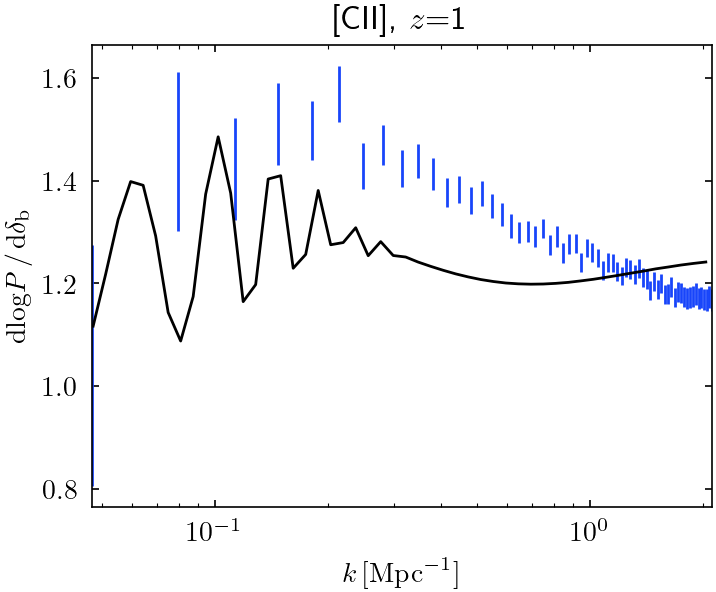

In [40]:
plt.errorbar(ki.to(u.Mpc**-1), ri, si, ls="")
plt.semilogx(kr, (BC + LD + HSV) / Phalo, "k")
plt.xlabel("$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel("$\mathrm{dlog}P\,/\,\mathrm{d}\delta_\mathrm{b}$")
plt.title("[CII], $z$=1")

# CO2-1

In [41]:
# Parameters for Astrophysics.
astrodict_CO21={
    "model_type": "ML",
    "model_name": "TonyLi",
    "model_par": {
        "alpha": 1.11,
        "beta": 0.6,
        "dMF": 1 * u.Msun * u.yr**-1 * u.Lsun**-1,
        "sig_SFR":0,
        "SFR_file": "sfr_release.dat",
        "do_quench": False,
    },
    "sigma_scatter" : 0.37,
    "meanperserve_scatter": False,
} # CO21

nu = 2 * 115.27 * u.GHz # CO(2-1)
surveyspecs_CO21 = get_specs(nu)

In [42]:
myssl = sslimpy.SSLimPy(
    settings_dict=settings,
    cosmopars=cosmodict,
    halopars=halodict,
    astropars=astrodict_CO21,
    obspars_dict=surveyspecs_CO21,
)

myastro = myssl.current_astro
mycosmo = myastro.cosmology
h = mycosmo.h()

  █████   █████  █       █            █████   █    █ 
 █     █ █     █ █            █   █   █    █  █   █  
 █       █       █     ███   █ █ █ █  █    █   █ █   
  █████   █████  █       █   █  █  █  █████     █    
       █       █ █       █   █     █  █        █     
 █     █ █     █ █       █   █     █  █       █      
  █████   █████  █████ █████ █     █  █      █       

#---------------------------------------------------#


/home/sefa/Desktop/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/fitting_functions/mass_luminosity.py:233: RuntimeWarning: divide by zero encountered in log10
  logL = np.log10(LIR.to(u.Lsun).value)


/home/sefa/Desktop/LIM-Code/SSC-project/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/sefa/Desktop/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/LIM-Code/SSC-project/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


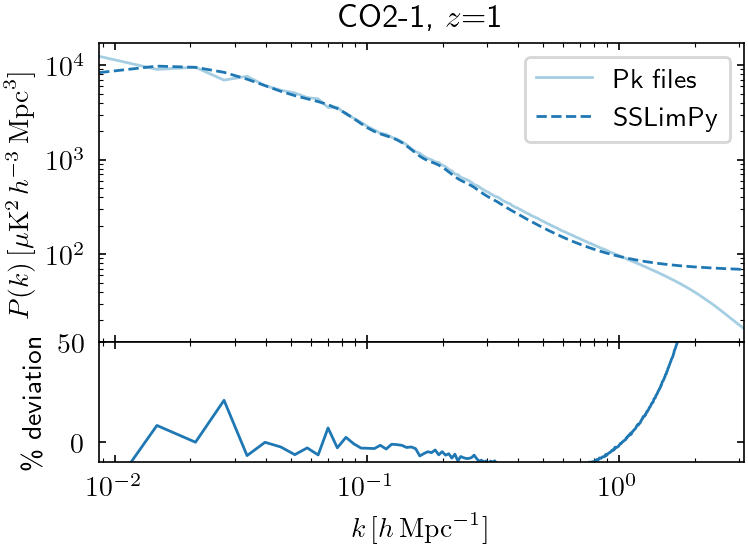

In [43]:
mithral_CII_Pk = np.load("/home/sefa/Desktop/LIM-Code/clusterdata/run_182753_CO21_Powerspectrum.npz")
k, Pk = mithral_CII_Pk["k"], mithral_CII_Pk["Pk"]
k = (k * myastro.Mpch**-1).to(myastro.Mpch**-1)
Pk = (Pk * myastro.Mpch**3 * u.uK**2).to(myastro.Mpch**3 * u.uK**2)

I11 = myastro.Thalo(1, k, p=1, scale=(1,), beta=1)
I02 = myastro.Thalo(1, k, p=1, scale=(2,), beta=0)
Pk_Lim_Solo = (I11**2) * mycosmo.matpow(k, 1) * 0.8 + I02

fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": [5, 2]})

axs[0].loglog(k, Pk, label="Pk files", c=Cp[0])
axs[0].loglog(k, Pk_Lim_Solo.to(myastro.Mpch**3 * u.uK**2), c=Cp[1],ls="--", label="SSLimPy")
axs[1].semilogx(k, ((Pk_Lim_Solo / Pk).to(1).value -1) * 100, c=Cp[1])
axs[0].legend()
axs[1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
axs[0].set_ylabel(r"$P(k)\,[\mu \mathrm{K}^2\,h^{-3}\,\mathrm{Mpc}^{3}]$")
axs[1].set_ylabel(r"\% deviation")
axs[0].set_title("CO2-1, $z$=1")
axs[1].set_ylim(-10, 50)

plt.tight_layout()
fig.subplots_adjust(hspace=0.0)

In [44]:
second = np.load("/home/sefa/Desktop/LIM-Code/clusterdata/run_183794_CO21_Response_NSUB8.npz")
ks, Pks, db = second["k"], second["Pkmean"], second["deltab"]
ks = (ks * myastro.Mpch**-1).to(myastro.Mpch**-1)

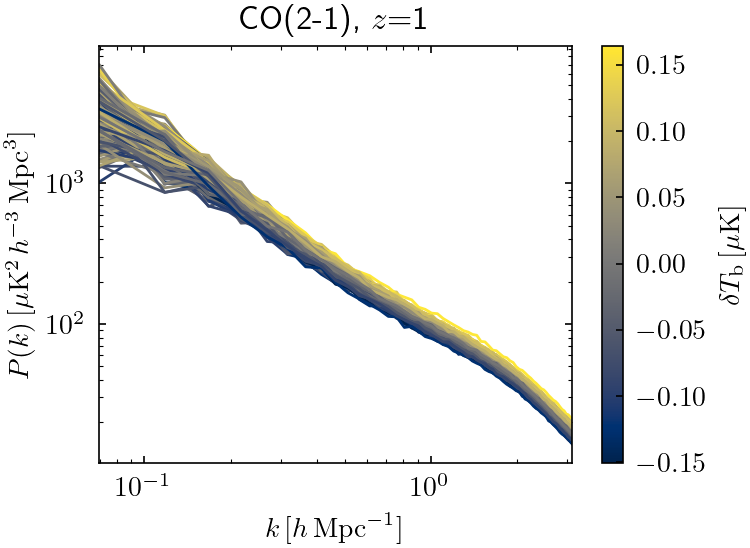

In [45]:
# Set up colormap normalization
norm = colors.Normalize(vmin=np.min(db), vmax=np.max(db))
cmap = cm.cividis
sm = cm.ScalarMappable(norm=norm, cmap=cmap)  # for the colorbar

# Plot
fig, ax = plt.subplots()
for i in range(Pks.shape[0]):
    color = cmap(norm(db[i]))
    ax.loglog(ks[i, :], Pks[i, :], color=color)

# Add colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\delta T_\mathrm{b}\,[\mu\mathrm{K}]$")

ax.set_title(r"CO(2-1), $z$=1")
ax.set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$P(k)\,[\mu \mathrm{K}^2\,h^{-3}\,\mathrm{Mpc}^{3}]$")
fig.tight_layout()
plt.show()

In [47]:
def linear(x, a, b):
    return a * x + b

pobs, pcov = [], []
for i in range(Pks.shape[1]):
    pi, ci = curve_fit(linear, db, Pks[:, i])
    pobs.append(pi)
    pcov.append(ci)
pobs = np.array(pobs)
pcov = np.array(pcov)

ai, bi = pobs[:, 0], pobs[:, 1]

ki = ks[0, :]
ri = myastro.Tavg(1).to(u.uK).value * ai / bi
si = ri * np.sqrt(pcov[:, 0, 0]/ ai**2 + pcov[:, 1, 1]/ bi**2 - 2 * bi / ai * pcov[:, 0, 1])

/tmp/ipykernel_26553/1165534172.py:15: RuntimeWarning: divide by zero encountered in divide
  ri = myastro.Tavg(1).to(u.uK).value * ai / bi
/tmp/ipykernel_26553/1165534172.py:16: RuntimeWarning: invalid value encountered in divide
  si = ri * np.sqrt(pcov[:, 0, 0]/ ai**2 + pcov[:, 1, 1]/ bi**2 - 2 * bi / ai * pcov[:, 0, 1])


In [49]:
kr = np.geomspace(7e-2, 3) * myastro.Mpch**-1

Delta = 4 * np.pi / (2 * np.pi)**3 * mycosmo.k**3 * mycosmo.matpow(mycosmo.k, 1, myastro.halomodel.tracer)
logD = np.log(Delta.to(1).value)

gamma = UnivariateSpline(np.log(mycosmo.k.value), logD, s=0).derivative(1)(np.log(kr.to(mycosmo.k.unit).value))
Pk = myastro.cosmology.matpow(kr, 1, myastro.halomodel.tracer)

In [50]:
I11 = myastro.Thalo(1, kr, p=1, scale=(1,), beta=1)
I02 = myastro.Thalo(1, kr, p=1, scale=(2,), beta=0)
I21 = (
    myastro.Thalo(1, kr, p=1, scale=(1,), beta="b2")
    + 4 / 3 * myastro.Thalo(1, kr, p=1, scale=(1,), beta="bG2")
)
I12 = myastro.Thalo(1, kr, p=1, scale=(2,), beta=1)

Phalo = I11**2 * Pk + I02

In [51]:
BC = (68 / 21 * I11**2 + 2 * I11 * I21) * Pk
LD = - 1 / 3 * gamma * I11**2 * Pk
HSV = I12

<>:3: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_26553/2292769605.py:3: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel("$k\,[\mathrm{Mpc}^{-1}]$")
/tmp/ipykernel_26553/2292769605.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathrm{dlog}P\,/\,\mathrm{d}\delta_\mathrm{b}$")


Text(0.5, 1.0, 'CO(2-1), $z$=1')

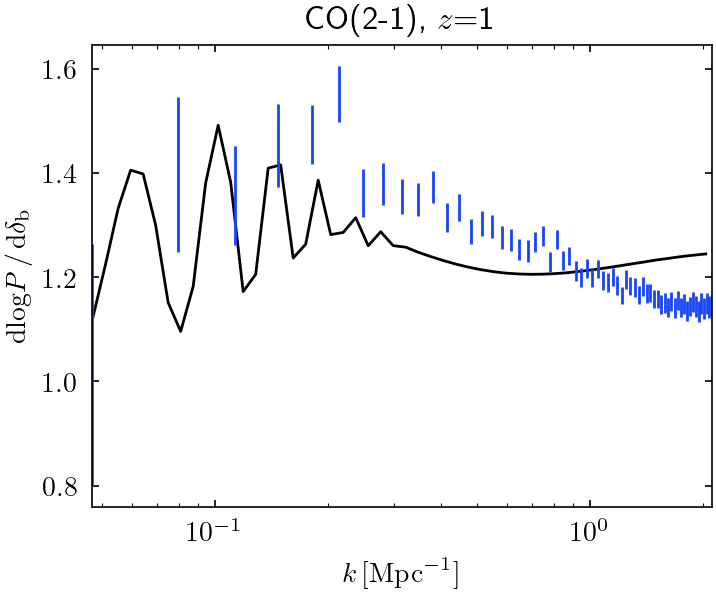

In [52]:
plt.semilogx(kr, (BC + LD + HSV) / Phalo, "k")
plt.errorbar(ki.to(u.Mpc**-1), ri, si, ls="")
plt.xlabel("$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel("$\mathrm{dlog}P\,/\,\mathrm{d}\delta_\mathrm{b}$")
plt.title("CO(2-1), $z$=1")